In [ ]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv('/content/sample_data/sentiment_analysis.csv')

In [ ]:
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df['target'].value_counts())
print("\nFirst 5 rows:")
df[['text', 'target']].head()


Shape: (7613, 5)

Column Names: ['id', 'keyword', 'location', 'text', 'target']

Missing Values:
 id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Target Distribution:
 target
0    4342
1    3271
Name: count, dtype: int64

First 5 rows:


,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
#1. Text Processing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()

    tokens = [w for w in tokens if w not in stop_words]

    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)


In [ ]:
df['cleaned_text'] = df['text'].apply(clean_text)

In [ ]:
df = df[df['cleaned_text'].str.strip() != '']

In [ ]:
print("Text cleaning done!")
print(f"Total records after cleaning: {df.shape[0]}")
print("\nExamples:")
for i in range(3):
    print(f"\nOriginal : {df['text'].iloc[i]}")
    print(f"Cleaned  : {df['cleaned_text'].iloc[i]}")

Text cleaning done!
Total records after cleaning: 7613

Examples:

Original : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Cleaned  : deed reason earthquake may allah forgive u

Original : Forest fire near La Ronge Sask. Canada
Cleaned  : forest fire near la ronge sask canada

Original : All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
Cleaned  : resident asked shelter place notified officer evacuation shelter place order expected


In [ ]:
#2. Vectorization
X = df['cleaned_text']
y = df['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 6090
Testing samples  : 1523


In [ ]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

In [ ]:
cv = CountVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
X_train_cv = cv.fit_transform(X_train)
X_test_cv  = cv.transform(X_test)

print(f"\nTF-IDF matrix shape  : {X_train_tfidf.shape}")
print(f"CountVec matrix shape: {X_train_cv.shape}")
print("\nVectorization complete!")


TF-IDF matrix shape  : (6090, 8977)
CountVec matrix shape: (6090, 8977)

Vectorization complete!


In [ ]:
#3. Naive Bayes Model
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train_cv, y_train)

y_pred_nb = nb.predict(X_test_cv)

nb_acc = accuracy_score(y_test, y_pred_nb)
nb_f1  = f1_score(y_test, y_pred_nb)

print("Naive Bayes Results")
print(f"  Accuracy  : {nb_acc:.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_nb):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_nb):.4f}")
print(f"  F1 Score  : {nb_f1:.4f}")

Naive Bayes Results
  Accuracy  : 0.8221
  Precision : 0.8579
  Recall    : 0.7018
  F1 Score  : 0.7721


In [ ]:
#4. Advanced Classification Models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM'          : LinearSVC(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

predictions = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    model.fit(X_train_tfidf, y_train)
    predictions[name] = model.predict(X_test_tfidf)
    print("Done")

print("\nAll models trained!")


Training Logistic Regression... Done
Training Linear SVM... Done
Training Random Forest... Done

All models trained!


In [ ]:
#5. Performance Evaluation
all_preds = {'Naive Bayes': y_pred_nb}
all_preds.update(predictions)

results = []
for name, y_pred in all_preds.items():
    results.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred), 4),
        'Recall'    : round(recall_score(y_test, y_pred), 4),
        'F1 Score'  : round(f1_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print(results_df.to_string(index=False))


              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.8240     0.8496  0.7171    0.7778
        Naive Bayes    0.8221     0.8579  0.7018    0.7721
         Linear SVM    0.7971     0.7717  0.7492    0.7603
      Random Forest    0.8011     0.7990  0.7171    0.7558


In [ ]:
# Detailed report for best model
best_name  = results_df.iloc[0]['Model']
best_preds = all_preds[best_name]
print(f"\nBest Model: {best_name}")
print(classification_report(y_test, best_preds,
      target_names=['Not Disaster', 'Disaster']))



Best Model: Logistic Regression
              precision    recall  f1-score   support

Not Disaster       0.81      0.90      0.85       869
    Disaster       0.85      0.72      0.78       654

    accuracy                           0.82      1523
   macro avg       0.83      0.81      0.82      1523
weighted avg       0.83      0.82      0.82      1523



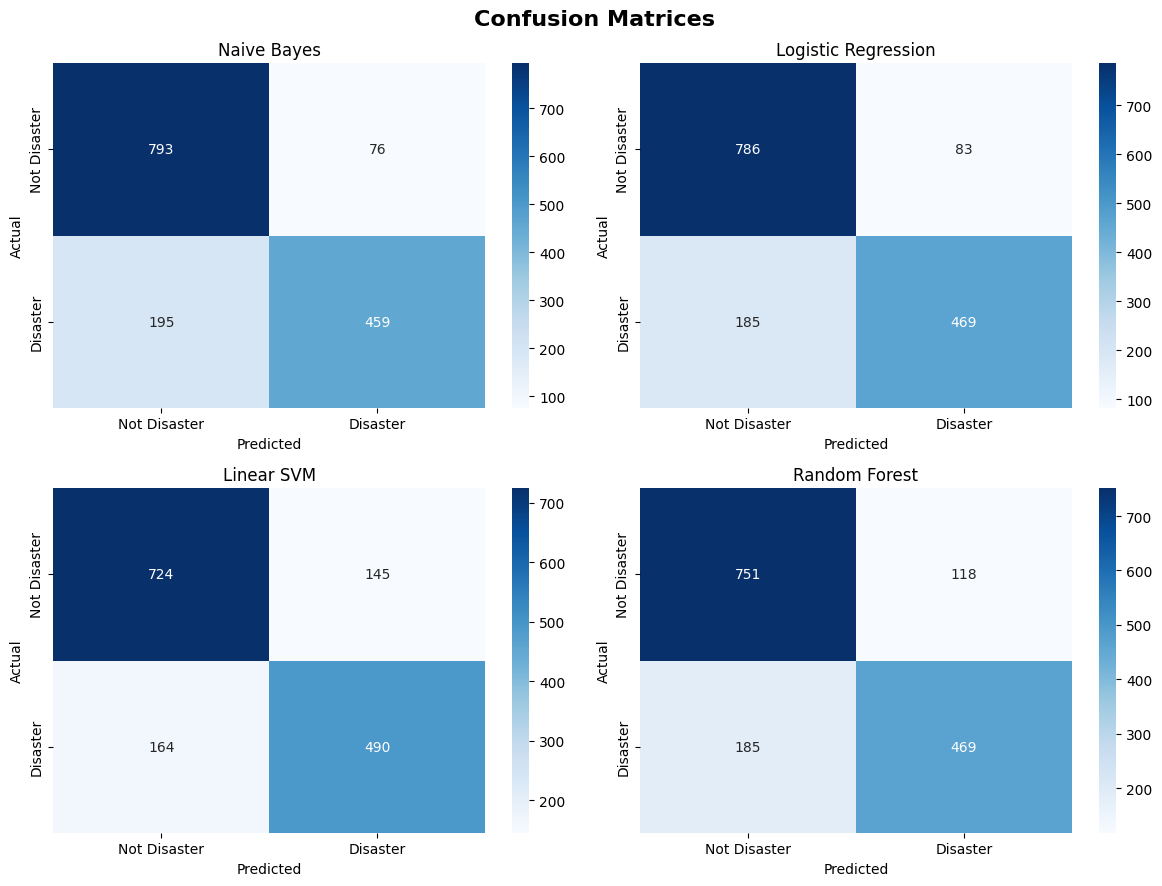

In [ ]:
#Confusion Matrix Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, (name, y_pred) in enumerate(all_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Disaster', 'Disaster'],
                yticklabels=['Not Disaster', 'Disaster'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

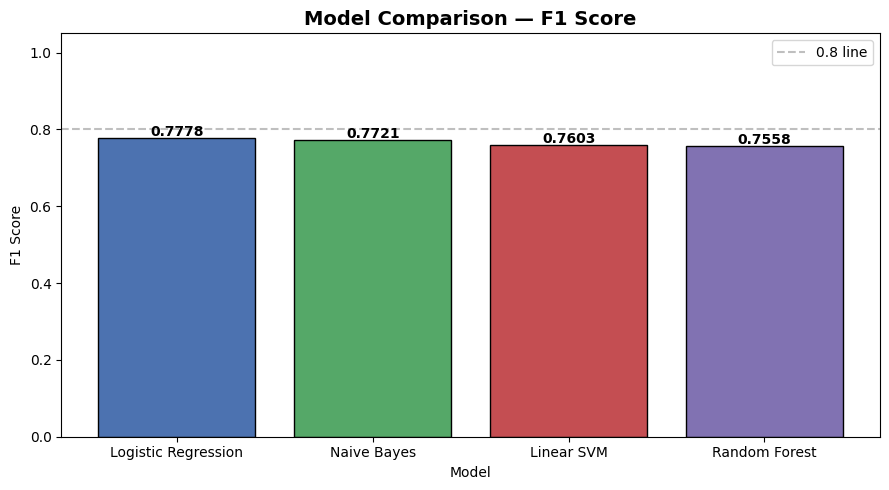

In [ ]:
# F1 Score Bar Chart
plt.figure(figsize=(9, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = plt.bar(results_df['Model'], results_df['F1 Score'],
               color=colors, edgecolor='black')

for bar, val in zip(bars, results_df['F1 Score']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             str(val), ha='center', fontweight='bold')

plt.title('Model Comparison — F1 Score', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.ylim(0, 1.05)
plt.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 line')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Cross Validation on Best Model
best_adv_name  = results_df[results_df['Model'] != 'Naive Bayes'].iloc[0]['Model']
best_adv_model = models[best_adv_name]

cv_scores = cross_val_score(best_adv_model, X_train_tfidf, y_train, cv=5, scoring='f1')

print(f"Cross Validation — {best_adv_name}")
print(f"Fold F1 Scores : {[round(s, 4) for s in cv_scores]}")
print(f"Mean F1        : {cv_scores.mean():.4f}")
print(f"Std Dev        : {cv_scores.std():.4f}")

Cross Validation — Logistic Regression
Fold F1 Scores : [np.float64(0.7155), np.float64(0.7465), np.float64(0.71), np.float64(0.7438), np.float64(0.7557)]
Mean F1        : 0.7343
Std Dev        : 0.0181
